In [12]:
"""
F1 RACE ANALYSIS - GP SÃO PAULO 2023
Part 1: Lap Time Analysis & Degradation
"""

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [13]:

# 1. CARREGAMENTO DE DADOS


print("🏎️  Carregando dados da corrida...")

# Habilitar cache para não recarregar sempre
fastf1.Cache.enable_cache('/workspaces/f1-race-analysis/cache')

# Carregar sessão
session = fastf1.get_session(2023, 'São Paulo', 'R')
session.load()

print(f"✅ Dados carregados: {session.event['EventName']}")
print(f"📅 Data: {session.event['EventDate']}")
print(f"🏁 Total de voltas: {session.total_laps}")

core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


🏎️  Carregando dados da corrida...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '14', '11', '18', '55', '10', '44', '22', '31', '2', '27', '3', '81', '63', '77', '24', '20', '23', '16']


✅ Dados carregados: São Paulo Grand Prix
📅 Data: 2023-11-05 00:00:00
🏁 Total de voltas: 71


In [14]:

# 2. ANÁLISE EXPLORATÓRIA


# Obter dados de voltas
laps = session.laps

print(f"\n📊 Shape dos dados: {laps.shape}")
print(f"🏎️  Pilotos na corrida: {laps['Driver'].nunique()}")

# Converter LapTime para segundos (mais fácil de trabalhar)
laps['LapTime_sec'] = laps['LapTime'].dt.total_seconds()

# Remover voltas inválidas (pit in/out, flags)
laps_clean = laps[
    (laps['LapTime_sec'].notna()) & 
    (laps['LapTime_sec'] > 0) &
    (laps['PitOutTime'].isna()) &  # Não é volta de saída do pit
    (laps['PitInTime'].isna())     # Não é volta de entrada no pit
].copy()

print(f"✅ Voltas válidas: {len(laps_clean)}/{len(laps)}")


📊 Shape dos dados: (1109, 31)
🏎️  Pilotos na corrida: 20
✅ Voltas válidas: 986/1109


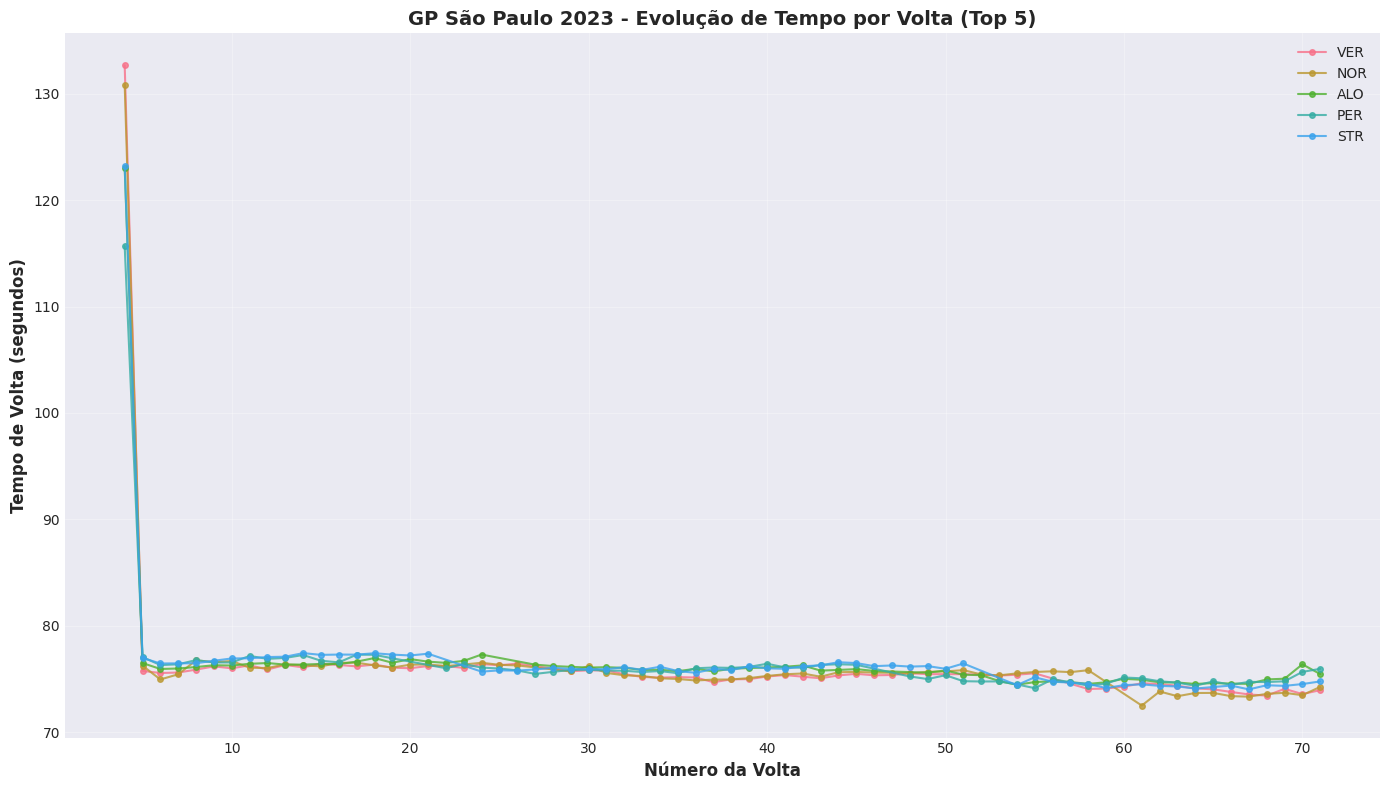

✅ Gráfico salvo: figures/01_lap_times_evolution.png


In [15]:

# 3. VISUALIZAÇÃO: EVOLUÇÃO DE TEMPO POR VOLTA


# Top 5 pilotos (por posição final)
results = session.results
top5_drivers = results.head(5)['Abbreviation'].tolist()

plt.figure(figsize=(14, 8))

for driver in top5_drivers:
    driver_laps = laps_clean[laps_clean['Driver'] == driver]
    
    plt.plot(
        driver_laps['LapNumber'], 
        driver_laps['LapTime_sec'],
        marker='o',
        markersize=4,
        label=driver,
        alpha=0.8
    )

plt.xlabel('Número da Volta', fontsize=12, fontweight='bold')
plt.ylabel('Tempo de Volta (segundos)', fontsize=12, fontweight='bold')
plt.title('GP São Paulo 2023 - Evolução de Tempo por Volta (Top 5)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/01_lap_times_evolution.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: figures/01_lap_times_evolution.png")

In [16]:

# 4. ANÁLISE DE DEGRADAÇÃO POR STINT


def calculate_degradation(driver_laps):
    """
    Calcula degradação de pneu por stint
    Degradação = (lap_time - primeira_volta_stint) / primeira_volta_stint * 100
    """
    degradation = []
    
    for stint in driver_laps['Stint'].unique():
        stint_laps = driver_laps[driver_laps['Stint'] == stint].copy()
        
        if len(stint_laps) < 3:  # Ignorar stints muito curtos
            continue
        
        first_lap_time = stint_laps.iloc[0]['LapTime_sec']
        
        stint_laps['Degradation_pct'] = (
            (stint_laps['LapTime_sec'] - first_lap_time) / first_lap_time * 100
        )
        
        degradation.append(stint_laps)
    
    return pd.concat(degradation) if degradation else pd.DataFrame()

# Calcular degradação para cada piloto
print("\n📉 ANÁLISE DE DEGRADAÇÃO POR STINT\n")

for driver in top5_drivers:
    driver_laps = laps_clean[laps_clean['Driver'] == driver].copy()
    deg_data = calculate_degradation(driver_laps)
    
    if not deg_data.empty:
        # Degradação média por stint
        deg_by_stint = deg_data.groupby('Stint')['Degradation_pct'].agg(['mean', 'max'])
        
        print(f"{driver}:")
        for stint, row in deg_by_stint.iterrows():
            compound = driver_laps[driver_laps['Stint'] == stint].iloc[0]['Compound']
            print(f"  Stint {int(stint)} ({compound}): "
                  f"Média={row['mean']:.2f}%, Máx={row['max']:.2f}%")
        print()


📉 ANÁLISE DE DEGRADAÇÃO POR STINT

VER:
  Stint 3 (SOFT): Média=-40.78%, Máx=0.00%
  Stint 4 (MEDIUM): Média=-0.52%, Máx=0.11%
  Stint 5 (SOFT): Média=-0.04%, Máx=0.73%

NOR:
  Stint 3 (SOFT): Média=-39.93%, Máx=0.00%
  Stint 4 (MEDIUM): Média=-0.32%, Máx=0.67%
  Stint 5 (SOFT): Média=1.42%, Máx=2.43%

ALO:
  Stint 3 (SOFT): Média=-36.05%, Máx=0.00%
  Stint 4 (MEDIUM): Média=-0.46%, Máx=0.00%
  Stint 5 (SOFT): Média=-0.83%, Máx=1.03%

PER:
  Stint 3 (SOFT): Média=-31.48%, Máx=0.00%
  Stint 4 (MEDIUM): Média=-0.04%, Máx=0.55%
  Stint 5 (SOFT): Média=-0.53%, Máx=0.95%

STR:
  Stint 3 (SOFT): Média=-35.38%, Máx=0.00%
  Stint 4 (MEDIUM): Média=0.47%, Máx=1.17%
  Stint 5 (SOFT): Média=0.03%, Máx=0.99%



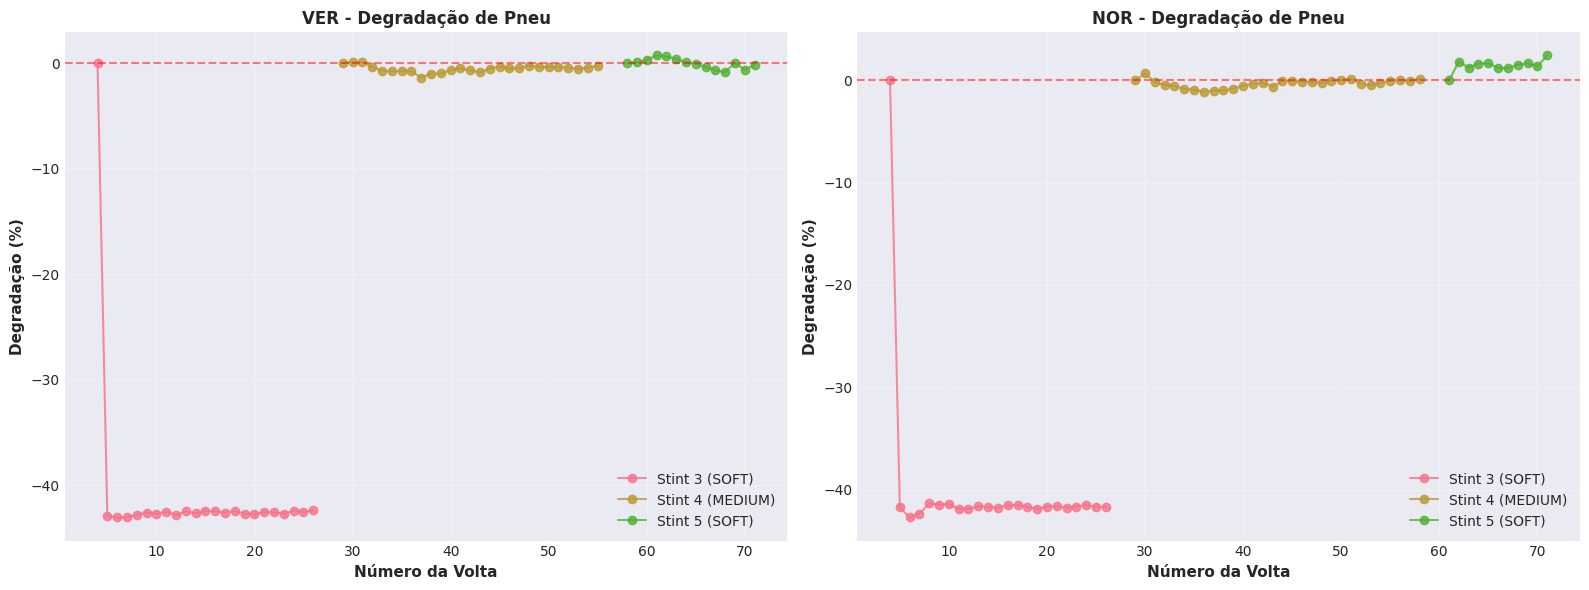

✅ Gráfico salvo: figures/02_tire_degradation_comparison.png


In [17]:

# 5. VISUALIZAÇÃO: DEGRADAÇÃO COMPARATIVA


# Escolher 2 pilotos para comparação detalhada
driver_a, driver_b = top5_drivers[0], top5_drivers[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, driver in enumerate([driver_a, driver_b]):
    driver_laps = laps_clean[laps_clean['Driver'] == driver].copy()
    deg_data = calculate_degradation(driver_laps)
    
    if not deg_data.empty:
        for stint in deg_data['Stint'].unique():
            stint_data = deg_data[deg_data['Stint'] == stint]
            compound = stint_data.iloc[0]['Compound']
            
            axes[idx].plot(
                stint_data['LapNumber'],
                stint_data['Degradation_pct'],
                marker='o',
                label=f"Stint {int(stint)} ({compound})",
                alpha=0.8
            )
        
        axes[idx].set_xlabel('Número da Volta', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Degradação (%)', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{driver} - Degradação de Pneu', 
                           fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/02_tire_degradation_comparison.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: figures/02_tire_degradation_comparison.png")

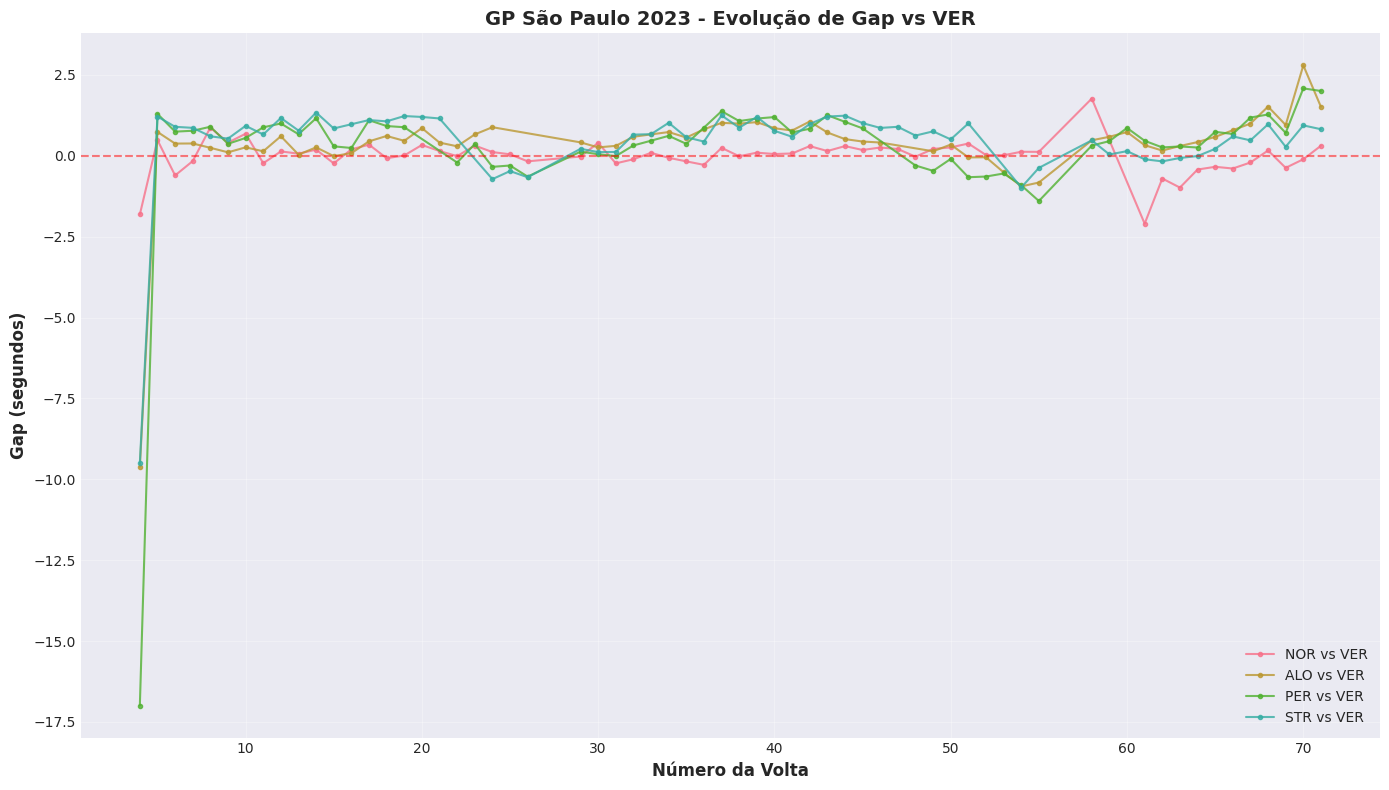

✅ Gráfico salvo: figures/03_gap_analysis.png


In [18]:

# 6. ANÁLISE DE GAP (DISTÂNCIA ENTRE PILOTOS)


def calculate_gaps(laps_df, reference_driver):
    """
    Calcula gap para piloto de referência ao longo da corrida
    """
    gaps = []
    
    for lap_num in laps_df['LapNumber'].unique():
        lap_data = laps_df[laps_df['LapNumber'] == lap_num]
        
        # Tempo do piloto de referência
        ref_time = lap_data[lap_data['Driver'] == reference_driver]['LapTime_sec']
        
        if ref_time.empty:
            continue
        
        ref_time = ref_time.values[0]
        
        # Calcular gap para todos os outros
        for _, row in lap_data.iterrows():
            if row['Driver'] != reference_driver:
                gap = row['LapTime_sec'] - ref_time
                gaps.append({
                    'LapNumber': lap_num,
                    'Driver': row['Driver'],
                    'Gap_sec': gap
                })
    
    return pd.DataFrame(gaps)

# Gap analysis: P1 vs resto do top 5
winner = top5_drivers[0]
gap_data = calculate_gaps(laps_clean, winner)

plt.figure(figsize=(14, 8))

for driver in top5_drivers[1:]:  # Excluir o winner
    driver_gaps = gap_data[gap_data['Driver'] == driver]
    
    plt.plot(
        driver_gaps['LapNumber'],
        driver_gaps['Gap_sec'],
        marker='o',
        markersize=3,
        label=f"{driver} vs {winner}",
        alpha=0.8
    )

plt.xlabel('Número da Volta', fontsize=12, fontweight='bold')
plt.ylabel('Gap (segundos)', fontsize=12, fontweight='bold')
plt.title(f'GP São Paulo 2023 - Evolução de Gap vs {winner}', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Referência')
plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/03_gap_analysis.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: figures/03_gap_analysis.png")

In [19]:

# 7. ESTATÍSTICAS FINAIS


print("\n📊 ESTATÍSTICAS FINAIS\n")

for driver in top5_drivers:
    driver_laps = laps_clean[laps_clean['Driver'] == driver]
    
    fastest = driver_laps['LapTime_sec'].min()
    slowest = driver_laps['LapTime_sec'].max()
    mean = driver_laps['LapTime_sec'].mean()
    std = driver_laps['LapTime_sec'].std()
    
    print(f"{driver}:")
    print(f"  Volta mais rápida: {fastest:.3f}s")
    print(f"  Volta mais lenta:  {slowest:.3f}s")
    print(f"  Média:             {mean:.3f}s")
    print(f"  Desvio padrão:     {std:.3f}s")
    print(f"  Total de voltas:   {len(driver_laps)}")
    print()


📊 ESTATÍSTICAS FINAIS

VER:
  Volta mais rápida: 73.422s
  Volta mais lenta:  132.670s
  Média:             76.200s
  Desvio padrão:     7.217s
  Total de voltas:   64

NOR:
  Volta mais rápida: 72.486s
  Volta mais lenta:  130.857s
  Média:             76.251s
  Desvio padrão:     7.005s
  Total de voltas:   64

ALO:
  Volta mais rápida: 74.442s
  Volta mais lenta:  123.054s
  Média:             76.499s
  Desvio padrão:     5.957s
  Total de voltas:   64

PER:
  Volta mais rápida: 74.124s
  Volta mais lenta:  115.677s
  Média:             76.363s
  Desvio padrão:     5.065s
  Total de voltas:   64

STR:
  Volta mais rápida: 74.007s
  Volta mais lenta:  123.170s
  Média:             76.582s
  Desvio padrão:     6.003s
  Total de voltas:   64



In [20]:

# 8. EXPORTAR DADOS PROCESSADOS


# Salvar dados limpos para análises futuras
laps_clean.to_csv('/workspaces/f1-race-analysis/data/processed/sao_paulo_2023_laps_clean.csv', index=False)
print("✅ Dados processados salvos: data/processed/sao_paulo_2023_laps_clean.csv")

print("\n🏁 Análise Parte 1 completa!")


✅ Dados processados salvos: data/processed/sao_paulo_2023_laps_clean.csv

🏁 Análise Parte 1 completa!
